In [5]:
from langgraph.graph import MessagesState

In [52]:
class MessagesState(MessagesState):
  pass

In [7]:
## For chat bot we need Interactive Message so first wen need LLM
import os
from google.colab import userdata
os.environ['GOOGLE_API_KEY']=userdata.get('GEMINI4')

In [8]:
pip install -U langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.6/561.6 kB 29.8 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.4.9
    Uninstalling langchain-core-1.4.9:
      Successfully uninstalled langchain-core-1.4.9


In [9]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash")

In [10]:
from langchain_core.messages import SystemMessage, HumanMessage

In [22]:
## Creating the Call model node

def Call_Model(state: MessagesState):
  summary=state.get('msg_summary','')
  if summary:
    system_msg=f"this is the previous conversitons {summary}"
    messages= state['messages']+[SystemMessage(content=system_msg)]
  else:
    messages= state['messages']
  return {'messages':[llm.invoke(state['messages'])]}

In [23]:
## Creating Summarzer

def Summarizer(state: MessagesState):
  summary=state.get('msg_summary','')
  if summary:
    summary_message=f" {summary} above content is summary of previous messages so kepp that in mind answer the user question acc to that "
  else:
    summary_message=f" Create a Summary of above conversation"

  messages=state['messages']+[HumanMessage(content=summary_message)]
  response= llm.invoke(state['messages'])
  return {'msg_summary':response.content, 'message': state['messages'] }

In [24]:
from langgraph.graph import StateGraph, START, END

In [25]:
graphvar=StateGraph(MessagesState)

In [26]:
graphvar.add_node('Summarizer', Summarizer)
graphvar.add_node('Call_Model', Call_Model)

In [27]:
graphvar.add_edge(START,'Call_Model' )
graphvar.add_edge('Call_Model' ,'Summarizer')
graphvar.add_edge('Summarizer', END)

In [28]:
from langgraph.checkpoint.memory import InMemorySaver

In [29]:
mem=InMemorySaver()

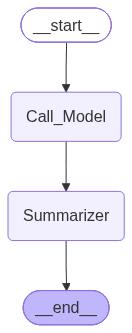

In [30]:
Graph=graphvar.compile(checkpointer=mem)
Graph

In [33]:
Graph.invoke({"messages":[SystemMessage(content='Give Response in small and simple words'),
                 HumanMessage(content=" My name is Chidvilas ")]},
             {'configurable': {'thread_id':'user1'}})

{'messages': [SystemMessage(content='Give Response in small and simple words', additional_kwargs={}, response_metadata={}, id='0a1bebd9-9e81-47b6-915e-fc496d2c9b6e'),
  HumanMessage(content=' My name is Chidvilas ', additional_kwargs={}, response_metadata={}, id='e57f8e7d-9857-4f2d-b7ac-fd4d49fea20f'),
  AIMessage(content='Hello Chidvilas!', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f9399-8599-7e01-8131-f87b9741f7cc-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 16, 'output_tokens': 32, 'total_tokens': 48, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 26}})]}

In [34]:
res=Graph.invoke({"messages":[HumanMessage(content="Suggest Acne removal Serums  ")]},
             {'configurable': {'thread_id':'user1'}})

In [35]:
for every in res['messages']:
  every.pretty_print()

================================ System Message ================================

Give Response in small and simple words
================================ Human Message =================================

 My name is Chidvilas 
================================== Ai Message ==================================

Hello Chidvilas!
================================ Human Message =================================

Suggest Acne removal Serums  
================================== Ai Message ==================================

Okay, for acne serums, look for these:

*   **Salicylic Acid:** Helps unclog pores.
*   **Niacinamide:** Reduces redness and inflammation.

Start with one, use a little, and see how your skin likes it.


In [36]:
res=Graph.invoke({"messages":[HumanMessage(content="Oliy, and i also used these they reduced acne but, they didnot able to remove acne marks and spots  ")]},
             {'configurable': {'thread_id':'user1'}})
for every in res['messages']:
  every.pretty_print()

================================ System Message ================================

Give Response in small and simple words
================================ Human Message =================================

 My name is Chidvilas 
================================== Ai Message ==================================

Hello Chidvilas!
================================ Human Message =================================

Suggest Acne removal Serums  
================================== Ai Message ==================================

Okay, for acne serums, look for these:

*   **Salicylic Acid:** Helps unclog pores.
*   **Niacinamide:** Reduces redness and inflammation.

Start with one, use a little, and see how your skin likes it.
================================ Human Message =================================

Oliy, and i also used these they reduced acne but, they didnot able to remove acne marks and spots  
================================== Ai Message ==================================

Okay, for **a

In [37]:
res=Graph.invoke({"messages":[HumanMessage(content="what is my name  ")]},
             {'configurable': {'thread_id':'user1'}})
for every in res['messages']:
  every.pretty_print()

================================ System Message ================================

Give Response in small and simple words
================================ Human Message =================================

 My name is Chidvilas 
================================== Ai Message ==================================

Hello Chidvilas!
================================ Human Message =================================

Suggest Acne removal Serums  
================================== Ai Message ==================================

Okay, for acne serums, look for these:

*   **Salicylic Acid:** Helps unclog pores.
*   **Niacinamide:** Reduces redness and inflammation.

Start with one, use a little, and see how your skin likes it.
================================ Human Message =================================

Oliy, and i also used these they reduced acne but, they didnot able to remove acne marks and spots  
================================== Ai Message ==================================

Okay, for **a

In [38]:
res=Graph.invoke({"messages":[HumanMessage(content="previously said that what iam suffrening with  ")]},
             {'configurable': {'thread_id':'user1'}})
for every in res['messages']:
  every.pretty_print()

================================ System Message ================================

Give Response in small and simple words
================================ Human Message =================================

 My name is Chidvilas 
================================== Ai Message ==================================

Hello Chidvilas!
================================ Human Message =================================

Suggest Acne removal Serums  
================================== Ai Message ==================================

Okay, for acne serums, look for these:

*   **Salicylic Acid:** Helps unclog pores.
*   **Niacinamide:** Reduces redness and inflammation.

Start with one, use a little, and see how your skin likes it.
================================ Human Message =================================

Oliy, and i also used these they reduced acne but, they didnot able to remove acne marks and spots  
================================== Ai Message ==================================

Okay, for **a